In [18]:
import os
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point

In [19]:
# Disable osmnx HTTP cache — no notebooks/cache/ directory created.
# Graph is persisted to data/processed/ so subsequent runs skip the download.
# Delete sd_walk_graph.graphml manually to force a re-download.
ox.settings.use_cache = False

_graphml_path = "../data/processed/sd_walk_graph.graphml"

if os.path.exists(_graphml_path):
    G = ox.load_graphml(_graphml_path)
else:
    G = ox.graph_from_place("San Diego, CA, USA", network_type="walk")
    ox.save_graphml(G, _graphml_path)

edges = ox.graph_to_gdfs(G, nodes=False)
print(f"CRS:         {edges.crs}")
print(f"Total edges: {len(edges):,}")
print(f"Bounds:      {edges.total_bounds}")


CRS:         epsg:4326
Total edges: 684,012
Bounds:      [-117.324036    32.5339564 -116.9075593   33.1144246]


In [20]:
# load in the crime, walkability, and light data
crime_gdf = gpd.read_file("../data/processed/crime_final_gdf.gpkg")
walkability_gdf = gpd.read_file("../data/processed/walkability_final_gdf.gpkg")
light_gdf = gpd.read_file("../data/processed/streetlights/streetlights_processed.geojson")

display(crime_gdf.head())
display(walkability_gdf.head())
display(light_gdf.head())


crime_gdf.describe()

,INCIDENT_NUM,DATE_TIME,DAY_OF_WEEK,ADDRESS_ROAD_PRIMARY,CALL_TYPE,DISPOSITION,PRIORITY,HOUR,geometry
0,E26040027846,2026-04-20 10:48:53,2.0,EL CAJON,415V,R,1.0,10,POINT (-117.06696 32.76148)
1,E26040027876,2026-04-20 11:07:54,2.0,C,242,R,1.0,11,POINT (-117.16002 32.71684)
2,E26040027882,2026-04-20 11:10:22,2.0,HOTEL CIRCLE SOUTH,415V,R,1.0,11,POINT (-117.17811 32.7589)
3,E26040027891,2026-04-20 11:15:24,2.0,LANDIS,242R,R,2.0,11,POINT (-117.12218 32.74549)
4,E26040028068,2026-04-20 13:20:46,2.0,AIR,415V,O,1.0,13,POINT (-117.09512 32.71952)


,GEOID,CBSA,CBSA_Name,TotPop,NatWalkInd,geometry
0,060730027122,41740.0,"San Diego-Chula Vista-Carlsbad, CA",1653,13.500000,"POLYGON ((-117.08306 32.72588, -117.0828 32.72..."
1,060730186012,41740.0,"San Diego-Chula Vista-Carlsbad, CA",3958,5.333333,"POLYGON ((-117.35296 33.22489, -117.35294 33.2..."
2,060730186093,41740.0,"San Diego-Chula Vista-Carlsbad, CA",2376,13.000000,"POLYGON ((-117.31819 33.25084, -117.31819 33.2..."
3,060730194063,41740.0,"San Diego-Chula Vista-Carlsbad, CA",1485,6.500000,"POLYGON ((-117.2737 33.19762, -117.27367 33.19..."
4,060730195032,41740.0,"San Diego-Chula Vista-Carlsbad, CA",1079,16.333333,"POLYGON ((-117.24344 33.20156, -117.24329 33.2..."


,sap_obj_nr,status,mapng_stat_cd,drawing_date,dup_sapobjnr_flag,data_quality_flag,geometry
0,IF?0100000000000243406,A,AB,None,0,ok,POINT (-117.23655 32.76638)
1,IF?0100000000000239557,A,AB,None,0,ok,POINT (-117.1539 32.72578)
2,IF?0100000000000243586,A,AB,None,0,ok,POINT (-117.23572 32.76619)
3,IF?0100000000000238417,A,AB,None,0,ok,POINT (-117.1091 32.71928)
4,IF?0100000000000238529,A,AB,None,0,ok,POINT (-117.10915 32.71963)


,DATE_TIME,DAY_OF_WEEK,PRIORITY,HOUR
count,45742,45742.000000,45742.000000,45742.000000
mean,2024-12-08 14:54:09.771000,3.993551,1.140877,12.945214
min,2024-01-01 00:08:14,1.000000,0.000000,0.000000
25%,2024-05-25 19:12:29.500000,2.000000,1.000000,9.000000
50%,2024-10-11 09:28:37,4.000000,1.000000,14.000000
75%,2025-06-20 05:17:35.750000,6.000000,1.000000,18.000000
max,2026-04-23 21:35:02,7.000000,9.000000,23.000000
std,NaN,2.024581,1.131213,6.466463


## Crime Scoring — Score Reference & Reasoning

Each crime row gets one `severity_score` based on its call type. The score bakes in two things together: **how serious is this crime** (FBI UCR hierarchy) and **how directly does it affect someone walking nearby** (pedestrian exposure). Both inform the single number — high seriousness + high exposure = 3.0; low seriousness + low exposure = 0.4.

**Score range:** 0.4 (lowest pedestrian risk) → 3.0 (maximum pedestrian danger)

---

### Score 3.0 — Maximum danger: direct lethal or predatory threat to a person on foot

**HOMICIDE**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `187` | Murder | Highest-severity crime possible. A confirmed murder nearby signals a lethal threat that has already materialized. Direct exposure — anyone in the vicinity is at risk from an offender who has demonstrated willingness to kill. |
| `187-SUSP` | Murder suspect at scene | Suspect still present at or near a murder scene. Active, armed, already proven lethal. Maximum score regardless of time of day. |

**KIDNAPPING**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `207` | Kidnapping in progress | Active predatory abduction of a person. The offender is physically targeting individuals on foot or nearby. Highest FBI tier, maximum direct pedestrian exposure. |
| `207R` | Kidnapping report | Predatory offender confirmed operating in this corridor. A pedestrian walking the same route faces demonstrated risk of targeted attack. |

**ASSAULT WITH DEADLY WEAPON**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `245` | ADW in progress | Active weapon assault on a person. Attacker is armed and already using a weapon — immediate lethal threat to any pedestrian in range. |
| `245-SUSP` | ADW suspect at scene | Armed suspect confirmed at scene of a weapon assault. |
| `245DV` | ADW domestic violence | Weapon assault in a domestic violence context — active scene, attacker potentially still present. |
| `245R` | ADW report | Pattern signal: a weapon assault happened in this corridor. Demonstrates the area has seen lethal-force incidents. |
| `417` | Threatening with weapon | Person actively threatening others with a weapon. Immediate danger to any pedestrian nearby. |
| `417R` | Threatening with weapon report | Recent weapon threat in this corridor — attacker not yet apprehended. |

**ROBBERY**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `211` | Robbery in progress | Active robbery — offender is using force or threat against victims right now. Direct, targeted threat to pedestrians. |
| `211-SUSP` | Robbery suspect at scene | Suspect still on scene of an active robbery. Extreme pedestrian exposure. |
| `211R` | Robbery report | Confirmed robbery pattern in this corridor. Pedestrians are the target. |
| `211C` | Robbery caser | Offender observed casing for robbery — pre-crime indicator of active targeting in this area. |

---

### Score 2.8 — High danger: targeted vehicle theft with potential violence

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `215` | Car jacking in progress | Active car jacking — attacker confronted the victim in a vehicle. High violence potential, pedestrians nearby are in the threat zone. |
| `215R` | Car jacking report | Confirmed carjacking in this corridor. Lower than in-progress but still a high pedestrian risk signal. |

---

### Score 2.4 — Significant danger: lethal force deployed or threatened at area level

**FIREARMS DISCHARGE**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `246` | Firing at occupied house/vehicle | Shots fired at an occupied structure or vehicle — bullets are moving through the public space a pedestrian would occupy. |
| `246R` | Firing at occupied house/vehicle report | Confirmed shooting incident in this corridor. Active shooter pattern in the area. |
| `247` | Firing at unoccupied vehicle | Shots fired at property — less immediately lethal than `246` but live rounds were discharged in the area. |
| `247R` | Firing at unoccupied vehicle report | Pattern of live-fire incidents in this corridor. |
| `11-6` | Discharging firearms | Shots fired in the area — any pedestrian in the corridor is in the trajectory zone. |
| `11-6SPT` | ShotSpotter activation | Acoustic gunshot detection confirmation. Shots fired, precise location confirmed by sensor. |

**BOMB / EXPLOSION**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `EXPLO` | Explosion | An explosion has occurred — immediate danger to anyone in the area. |
| `ALERT4` | Bomb/hijack threat | Confirmed credible bomb or hijack threat. Law enforcement response, area cordoned. |
| `BOMB` | Bomb threat | Active bomb threat at a location in this corridor. |
| `BOMB-S` | Bomb threat (school) | School-located bomb threat — area likely under evacuation, elevated pedestrian/civilian exposure. |

---

### Score 2.0 — Moderate-high danger: direct physical assault or credible personal threats

**BATTERY**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `242` | Battery in progress | Physical assault actively occurring. The attacker is already using force against a person. |
| `242R` | Battery report | Confirmed physical assault in this corridor. Pattern signal for pedestrian risk. |

**THREATS / STALKING**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `422` | Criminal threats | Explicit criminal threat against a person — escalation to violence is credible. |
| `422R` | Criminal threats report | Documented criminal threat in this area. |
| `136` | Intimidation of witness | Witness intimidation — organized threat activity operating in this corridor. |
| `646` | Stalking | Active stalking — targeted predatory behavior against a specific person in this area. |
| `646R` | Stalking report | Documented stalking pattern in this corridor. |
| `653M` | Threatening phone call report | Credible threat made by phone — attacker has identified a target in this area. |
| `415W` | Disturbing peace with unconcealed weapon | Person carrying a weapon visibly in public — immediate intimidation threat to pedestrians nearby. |

---

### Score 1.6 — Moderate danger: escalating situation or violent disturbance

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `415V` | Disturbing peace with violence | Active violent disturbance — physical altercation in a public area, pedestrians nearby are at risk. |
| `415DV` | Domestic violence occurring now | Active domestic violence incident — volatile, often escalates, anyone nearby is in the danger zone. |
| `5150V` | Mental case — violent or urgent | Violent psychiatric crisis. Person is in active distress and has been violent or is imminently likely to be. |
| `FP` | Foot pursuit | Police foot pursuit underway — suspect is fleeing through pedestrian areas. |
| `ESCAPE` | Escape / escapee | A person has escaped from custody. Apprehension in progress, may pass through pedestrian corridors. |

---

### Score 1.2 — Lower-moderate: property crime with some pedestrian exposure

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `451` | Arson in progress | Active fire-setting — immediate hazard to anyone in the area. |
| `451R` | Arson report | Confirmed arson in this corridor — fire hazard and pattern indicator. |

---

### Score 0.8 — Low-moderate: opportunistic entry crime

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `459HP` | Burglary hot prowl | Burglar entered an occupied residence — high aggression indicator, offender willing to confront occupants. Moderate pedestrian exposure. |

---

### Score 0.6 — Low: property or area concern, indirect pedestrian risk

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `459` | Burglary in progress | Active break-in underway — offender present, may encounter pedestrians. |
| `459-SUSP` | Burglary suspect at scene | Burglary suspect still on scene. Property crime but offender is nearby. |
| `11-7` | Prowler | Person prowling — potential precursor to break-in or assault. Low but real pedestrian exposure. |
| `CCW` | Carrying concealed weapon | Person confirmed carrying a concealed weapon — indirect threat. Not active, but a signal of armed presence. |
| `NARC` | Narcotics activity | Drug activity in the area — correlates with other violent crime. Indirect pedestrian exposure. |
| `647F` | Drunk/drugs in public | Intoxicated person in public — unpredictable behavior, low but real risk to passersby. |
| `HATEINV` | Hate crime investigation | Hate crime confirmed in this corridor — targeted aggression toward specific groups. |
| `AUHATE` | Hate incident all units | Active hate incident with all-units notification — broader area under advisory. |
| `HZRD` | Hazardous condition | General hazard — chemical spill, structural, or similar. Not violent but real danger to pedestrians. |
| `1155` | Hazardous/chemical spill | Chemical spill — evacuate the area, pedestrian exposure to toxic hazard. |

---

### Score 0.4 — Minimal: low pedestrian exposure, background environment indicator

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `602` | Trespassing | Unauthorized presence — lowest active threat to pedestrians. Background indicator of area quality. |
| `314` | Indecent exposure | Public indecency — low physical danger but discomfort signal for pedestrian experience. |
| `314R` | Indecent exposure report | Documented indecency pattern in this corridor. |
| `ANIMAL` | Vicious animal | Potentially dangerous animal — real but low-probability threat to a pedestrian walking by. |


In [21]:
# ── SEVERITY_MAP ──────────────────────────────────────────────────────────
# Maps each SDPD call type to (crime_category, severity_score).
#
# Each score bakes in both crime severity (FBI UCR hierarchy) and how directly
# a pedestrian is exposed to the threat. See markdown cell above for full
# per-call-type reasoning.
#
# Source: docs/references/pd_cfs_calltypes_datasd.csv

SEVERITY_MAP = {
    # ── HOMICIDE  [Score 3.0] ──────────────────────────────────────────────
    "187":       ("HOMICIDE",             3.0),
    "187-SUSP":  ("HOMICIDE",             3.0),

    # ── KIDNAPPING  [Score 3.0] ────────────────────────────────────────────
    "207":       ("KIDNAPPING",           3.0),
    "207R":      ("KIDNAPPING",           3.0),

    # ── ASSAULT WITH WEAPON  [Score 3.0] ──────────────────────────────────
    "245":       ("ASSAULT_WITH_WEAPON",  3.0),
    "245-SUSP":  ("ASSAULT_WITH_WEAPON",  3.0),
    "245DV":     ("ASSAULT_WITH_WEAPON",  3.0),
    "245R":      ("ASSAULT_WITH_WEAPON",  3.0),
    "417":       ("ASSAULT_WITH_WEAPON",  3.0),
    "417R":      ("ASSAULT_WITH_WEAPON",  3.0),

    # ── ROBBERY  [Score 3.0] ───────────────────────────────────────────────
    "211":       ("ROBBERY",              3.0),
    "211-SUSP":  ("ROBBERY",             3.0),
    "211R":      ("ROBBERY",              3.0),
    "211C":      ("ROBBERY",              3.0),

    # ── CARJACKING  [Score 2.8] ────────────────────────────────────────────
    "215":       ("CARJACKING",           2.8),
    "215R":      ("CARJACKING",           2.8),

    # ── FIREARMS DISCHARGE  [Score 2.4] ───────────────────────────────────
    "246":       ("FIREARMS_DISCHARGE",   2.4),
    "246R":      ("FIREARMS_DISCHARGE",   2.4),
    "247":       ("FIREARMS_DISCHARGE",   2.4),
    "247R":      ("FIREARMS_DISCHARGE",   2.4),
    "11-6":      ("FIREARMS_DISCHARGE",   2.4),
    "11-6SPT":   ("FIREARMS_DISCHARGE",   2.4),

    # ── BOMB / EXPLOSION  [Score 2.4] ─────────────────────────────────────
    "EXPLO":     ("BOMB_EXPLOSION",       2.4),
    "ALERT4":    ("BOMB_EXPLOSION",       2.4),
    "BOMB":      ("BOMB_EXPLOSION",       2.4),
    "BOMB-S":    ("BOMB_EXPLOSION",       2.4),

    # ── BATTERY  [Score 2.0] ───────────────────────────────────────────────
    "242":       ("BATTERY",              2.0),
    "242R":      ("BATTERY",              2.0),

    # ── THREATS / STALKING  [Score 2.0] ───────────────────────────────────
    "422":       ("THREATS_STALKING",     2.0),
    "422R":      ("THREATS_STALKING",     2.0),
    "136":       ("THREATS_STALKING",     2.0),
    "646":       ("THREATS_STALKING",     2.0),
    "646R":      ("THREATS_STALKING",     2.0),
    "653M":      ("THREATS_STALKING",     2.0),
    "415W":      ("THREATS_STALKING",     2.0),

    # ── VIOLENT DISTURBANCE  [Score 1.6] ──────────────────────────────────
    "415V":      ("VIOLENT_DISTURBANCE",  1.6),
    "415DV":     ("VIOLENT_DISTURBANCE",  1.6),
    "5150V":     ("VIOLENT_DISTURBANCE",  1.6),
    "FP":        ("VIOLENT_DISTURBANCE",  1.6),
    "ESCAPE":    ("VIOLENT_DISTURBANCE",  1.6),

    # ── ARSON  [Score 1.2] ─────────────────────────────────────────────────
    "451":       ("ARSON_BURGLARY",       1.2),
    "451R":      ("ARSON_BURGLARY",       1.2),

    # ── BURGLARY HOT PROWL  [Score 0.8] ───────────────────────────────────
    "459HP":     ("ARSON_BURGLARY",       0.8),

    # ── BURGLARY IN PROGRESS  [Score 0.6] ─────────────────────────────────
    "459":       ("ARSON_BURGLARY",       0.6),
    "459-SUSP":  ("ARSON_BURGLARY",       0.6),

    # ── AREA SAFETY  [Score 0.6] ───────────────────────────────────────────
    "11-7":      ("AREA_SAFETY",          0.6),
    "CCW":       ("AREA_SAFETY",          0.6),
    "NARC":      ("AREA_SAFETY",          0.6),
    "647F":      ("AREA_SAFETY",          0.6),
    "HATEINV":   ("AREA_SAFETY",          0.6),
    "AUHATE":    ("AREA_SAFETY",          0.6),
    "HZRD":      ("AREA_SAFETY",          0.6),
    "1155":      ("AREA_SAFETY",          0.6),
    "602":       ("AREA_SAFETY",          0.4),

    # ── PUBLIC NUISANCE  [Score 0.4] ──────────────────────────────────────
    "314":       ("PUBLIC_NUISANCE",      0.4),
    "314R":      ("PUBLIC_NUISANCE",      0.4),
    "ANIMAL":    ("PUBLIC_NUISANCE",      0.4),
}

# ── Time-of-day multipliers ────────────────────────────────────────────────
# Keyed by crime_category. Categories not listed default to 1.0 (no adjustment).

NIGHT_MULTIPLIER = {
    "ROBBERY":             1.3,
    "ASSAULT_WITH_WEAPON": 1.3,
    "BATTERY":             1.2,
    "THREATS_STALKING":    1.2,
    "VIOLENT_DISTURBANCE": 1.2,
    "KIDNAPPING":          1.15,
    "AREA_SAFETY":         1.15,
    "PUBLIC_NUISANCE":     1.1,
}

DAY_MULTIPLIER = {
    "ROBBERY":        1.1,
    "ARSON_BURGLARY": 1.1,
}

In [22]:
# ── Feature engineering: severity_score, time_multiplier, combined_weight ─

_default = ("UNKNOWN", 0.4)  # fallback: lowest pedestrian exposure score

crime_gdf["crime_category"] = crime_gdf["CALL_TYPE"].map(
    lambda c: SEVERITY_MAP.get(c, _default)[0]
)
crime_gdf["severity_score"] = crime_gdf["CALL_TYPE"].map(
    lambda c: SEVERITY_MAP.get(c, _default)[1]
)

# Classify each incident by actual hour of occurrence
crime_gdf["time_of_day"] = np.where(crime_gdf["HOUR"].between(6, 20), "day", "night")

# Look up the per-category multiplier for the actual time this crime occurred
crime_gdf["time_multiplier"] = np.where(
    crime_gdf["time_of_day"] == "night",
    crime_gdf["crime_category"].map(NIGHT_MULTIPLIER).fillna(1.0),
    crime_gdf["crime_category"].map(DAY_MULTIPLIER).fillna(1.0),
)

# Final weight — not capped; normalization happens at the edge-score aggregation step
crime_gdf["combined_weight"] = crime_gdf["severity_score"] * crime_gdf["time_multiplier"]

# Split for spatial join step
crimes_day   = crime_gdf[crime_gdf["time_of_day"] == "day"]
crimes_night = crime_gdf[crime_gdf["time_of_day"] == "night"]

# Sanity checks
unmapped = crime_gdf.loc[crime_gdf["crime_category"] == "UNKNOWN", "CALL_TYPE"].unique().tolist()
print(f"Total: {len(crime_gdf):,}  |  Day: {len(crimes_day):,}  |  Night: {len(crimes_night):,}")
print(f"Unmapped call types: {unmapped if unmapped else 'none'}")

Total: 45,742  |  Day: 32,660  |  Night: 13,082
Unmapped call types: none


In [23]:
cols = ["CALL_TYPE", "crime_category", "time_of_day", "severity_score", "time_multiplier", "combined_weight"]
print(crime_gdf[cols].sample(10, random_state=42).to_string(index=False))
print()
print(crime_gdf["combined_weight"].describe().round(3))

CALL_TYPE      crime_category time_of_day  severity_score  time_multiplier  combined_weight
       FP VIOLENT_DISTURBANCE         day             1.6             1.00             1.60
     415W    THREATS_STALKING       night             2.0             1.20             2.40
     11-7         AREA_SAFETY       night             0.6             1.15             0.69
     NARC         AREA_SAFETY       night             0.6             1.15             0.69
      242             BATTERY       night             2.0             1.20             2.40
      211             ROBBERY       night             3.0             1.30             3.90
      417 ASSAULT_WITH_WEAPON         day             3.0             1.00             3.00
     647F         AREA_SAFETY         day             0.6             1.00             0.60
      242             BATTERY         day             2.0             1.00             2.00
    459HP      ARSON_BURGLARY       night             0.8             1.00      

## Crime scoring — output reference

### Columns added to `crime_gdf`

| Column | Type | Description |
| - | - | - |
| `crime_category` | string | Broad category the call type belongs to (e.g. `ROBBERY`, `BATTERY`) |
| `severity_score` | float | Pre-computed danger score for this call type (0.4 – 3.0) |
| `time_of_day` | string | `"day"` (HOUR 6–20) or `"night"` (HOUR 21–5), based on actual incident hour |
| `time_multiplier` | float | Category-level adjustment for time of day; 1.0 for categories not listed |
| `combined_weight` | float | `severity_score × time_multiplier` — aggregated per OSM edge in the spatial join |

### Severity scores — quick reference

| Score | Categories |
| - | - |
| 3.0 | HOMICIDE, KIDNAPPING, ASSAULT_WITH_WEAPON, ROBBERY |
| 2.8 | CARJACKING |
| 2.4 | FIREARMS_DISCHARGE, BOMB_EXPLOSION |
| 2.0 | BATTERY, THREATS_STALKING |
| 1.6 | VIOLENT_DISTURBANCE |
| 1.2 | ARSON_BURGLARY (arson only: `451`, `451R`) |
| 0.8 | ARSON_BURGLARY (hot prowl: `459HP`) |
| 0.6 | ARSON_BURGLARY (burglary in progress: `459`, `459-SUSP`), AREA_SAFETY |
| 0.4 | AREA_SAFETY (trespassing: `602`), PUBLIC_NUISANCE |

### Time multipliers

**Night (HOUR 21–5)**

| Category | Multiplier |
| - | - |
| ROBBERY | 1.3 |
| ASSAULT_WITH_WEAPON | 1.3 |
| BATTERY | 1.2 |
| THREATS_STALKING | 1.2 |
| VIOLENT_DISTURBANCE | 1.2 |
| KIDNAPPING | 1.15 |
| AREA_SAFETY | 1.15 |
| PUBLIC_NUISANCE | 1.1 |

**Day (HOUR 6–20)**

| Category | Multiplier |
| - | - |
| ROBBERY | 1.1 |
| ARSON_BURGLARY | 1.1 |

All other categories: `time_multiplier = 1.0`

### Feeds downstream

`crimes_day` and `crimes_night` feed the spatial join step, which sums `combined_weight` for all crimes within a 50 m buffer of each OSM edge:

```
crime_score_day   = sum(combined_weight) for day crimes within 50 m
crime_score_night = sum(combined_weight) for night crimes within 50 m
```

Both are normalized across all edges before entering the final `safety_score`.

## Crime Score Per Edge

For each OSM edge, this step counts how much crime happened nearby by
summing the `combined_weight` of all SDPD incidents within a spatial buffer.

### Bug Fixed — `.fillna(0.5)` Never Fired

The original implementation used:

```python
edges["crime_score_day"] = 1 - (np.log1p(raw) / np.log1p(raw).max())
edges["crime_score_day"] = edges["crime_score_day"].fillna(0.5)
```

`groupby().sum()` returns **0** (not NaN) for edges with no crime matches.
So for no-crime edges: `log1p(0) = 0`, `1 - (0/max) = 1.0` — assigned
directly as a real number. The `.fillna(0.5)` never saw a NaN and never
fired. Every no-crime edge scored 1.0. With ~45k incidents across 684k
edges, ~76% of the network was stuck at exactly 1.0 and completely
indistinguishable. The crime signal was effectively dead for most of the map.

**Fix:** separate zero-crime edges with a boolean mask BEFORE the log math,
assign 0.5 explicitly, normalize by p95 not max.

### Why 0.5 For No-Crime Edges

An edge with zero crime in a 100m buffer could be genuinely safe,
underreported, or a park path rarely logged by SDPD. We cannot tell which.
0.5 is the honest answer: no signal, treat as neutral. This makes the
system internally consistent — every score uses the same convention:

| Score | No data behaviour |
|---|---|
| `light_score` | no streetlights within 30m → 0.5 |
| `walk_score` | edge outside block group → 0.5 |
| `crime_score` | no crime within buffer → 0.5 |

### Dynamic Buffer — Why Three Sizes

A fixed 100m buffer works well for routes over 500m but causes
over-smoothing on short routes. When a route is only 2-3 edges long,
every edge shares the same crime catchment area and the safe/fast routes
become indistinguishable. To fix this, every edge is scored at three
buffer sizes and stored. The router picks the right one at query time.

| Column | Buffer | Used for | What it captures |
|---|---|---|---|
| `crime_score_short_day/night` | 50m | routes < 500m | Immediate pavement environment — granular, edge-level |
| `crime_score_medium_day/night` | 100m | routes 500m–2km | Block-level environment — current default |
| `crime_score_long_day/night` | 150m | routes > 2km | Neighbourhood character — averages across many edges |

`crime_score_day` and `crime_score_night` remain as backward-compatible
aliases for the medium (100m) buffer.

### Why Log-Normalize

A small number of downtown and border corridor edges accumulate very high
raw crime totals. Without log normalization those outliers compress every
other edge into a narrow band near 1.0 — making crime useless as a
differentiating signal. `log1p(x)` spreads the mid-range while preserving
relative ordering. p95 normalization (not max) prevents one extreme outlier
from compressing the rest of the distribution — the same fix applied to
`light_score` v0.

### Why These Buffer Sizes

- **50m** — captures the street itself and immediate pavements. At this
  resolution every edge has a meaningfully different crime neighbourhood.
  Appropriate when the whole route is only 2-4 edges long.
- **100m** — one full city block in all directions. An assault 80m away
  affects a pedestrian on the adjacent street. Block-level risk is the
  right signal for typical SD walking routes (500m-2km).
- **150m** — two blocks. Appropriate for longer routes where individual
  edge precision matters less than overall corridor character. Captures
  the broader neighbourhood safety signal.

### Score Direction

Higher = less crime nearby = safer for a pedestrian.

| Value | Meaning |
|---|---|
| 0.5 | No SDPD incidents within buffer — neutral, not penalised |
| ~0.4 | Low crime density in this corridor |
| ~0.2 | Moderate crime density |
| ~0.0 | Highest crime density edge in the network (p95 anchor) |

**Day vs Night split:** incidents are split by `time_of_day` before the
spatial join. `crime_score_*_day` uses HOUR 6-20; `crime_score_*_night`
uses HOUR 21-5. Severity scores and time multipliers are applied before
the spatial join via `combined_weight = severity_score x time_multiplier`.


In [24]:
# ── Dynamic crime score buffer ────────────────────────────────────────────
#
# WHY DYNAMIC BUFFER
# ------------------
# A fixed 100m buffer works well for routes over 500m but causes
# over-smoothing on short routes (< 500m). When a route is only 2-3 edges
# long, every edge shares the same 100m crime catchment area and the
# safe/fast routes become indistinguishable.
#
# SOLUTION — THREE PRE-COMPUTED BUFFER SIZES
# -------------------------------------------
# Score every edge at three buffers and store all three.
# The router picks the right score at query time based on route length.
#
#   50m  -> short routes  (< 500m)   — immediate pavement environment
#   100m -> medium routes (500m-2km) — block-level environment (current)
#   150m -> long routes   (> 2km)    — neighbourhood character
#
# All three use the same fix: p95 normalization + explicit 1.0 score
# for zero-crime edges (not fillna).
# 1.0 = safe — absence of crime is a positive signal, not neutral.
# Unlike lighting where no data = genuine uncertainty, no crime in SDPD
# data means no recorded incidents — a clean record is a good signal.

edges_3857 = edges.to_crs('EPSG:3857')
crimes_day_3857   = crimes_day[['combined_weight', 'geometry']].to_crs('EPSG:3857')
crimes_night_3857 = crimes_night[['combined_weight', 'geometry']].to_crs('EPSG:3857')

def compute_crime_score(raw_counts, fallback=1):
    scores = pd.Series(index=raw_counts.index, dtype=float)
    has_crime = raw_counts > 0
    no_crime  = ~has_crime
    if has_crime.any():
        log_raw = np.log1p(raw_counts[has_crime])
        p95     = log_raw.quantile(0.95)
        if p95 > 0:
            scores[has_crime] = (1 - (log_raw / p95).clip(0, 1))
        else:
            scores[has_crime] = fallback
    scores[no_crime] = fallback
    return scores.clip(0, 1)

def run_spatial_join(edges_3857, crimes_day_3857, crimes_night_3857, buffer_m):
    buffered = edges_3857.copy()
    buffered['geometry'] = edges_3857.geometry.buffer(buffer_m)
    j_day   = gpd.sjoin(buffered[['geometry']], crimes_day_3857,   how='left', predicate='contains')
    j_night = gpd.sjoin(buffered[['geometry']], crimes_night_3857, how='left', predicate='contains')
    raw_day   = j_day.groupby(j_day.index)['combined_weight'].sum().reindex(edges_3857.index, fill_value=0)
    raw_night = j_night.groupby(j_night.index)['combined_weight'].sum().reindex(edges_3857.index, fill_value=0)
    return raw_day, raw_night

BUFFER_CONFIGS = [
    ('short',  50,  'routes < 500m'),
    ('medium', 100, 'routes 500m-2km'),
    ('long',   150, 'routes > 2km'),
]

raw_crime_day   = None
raw_crime_night = None

for name, buffer_m, description in BUFFER_CONFIGS:
    print(f'Computing {name} buffer ({buffer_m}m) — {description}...')
    r_day, r_night = run_spatial_join(
        edges_3857, crimes_day_3857, crimes_night_3857, buffer_m
    )
    edges[f'crime_score_{name}_day']   = compute_crime_score(r_day)
    edges[f'crime_score_{name}_night'] = compute_crime_score(r_night)
    if name == 'medium':
        raw_crime_day   = r_day
        raw_crime_night = r_night
    crime_d = (r_day > 0).sum()
    crime_n = (r_night > 0).sum()
    print(f'  Day   — crime-influenced: {crime_d:,} ({100*crime_d/len(edges):.1f}%), zero-crime: {(r_day==0).sum():,}')
    print(f'  Night — crime-influenced: {crime_n:,} ({100*crime_n/len(edges):.1f}%), zero-crime: {(r_night==0).sum():,}')

edges['crime_score_day']   = edges['crime_score_medium_day']
edges['crime_score_night'] = edges['crime_score_medium_night']

print('\n--- Score comparison across buffer sizes (day, crime-influenced edges only) ---')
print(f'{"Stat":<8}', end='')
for name, buffer_m, _ in BUFFER_CONFIGS:
    print(f'  {(name+" ("+str(buffer_m)+"m)"):>14}', end='')
print()
print('-' * 52)
for stat in ['mean', 'std', 'min', '50%', 'max']:
    print(f'{stat:<8}', end='')
    for name, _, _ in BUFFER_CONFIGS:
        col = f'crime_score_{name}_day'
        val = edges[edges[col] != 0.5][col].describe()[stat]
        print(f'  {val:>14.3f}', end='')
    print()


Computing short buffer (50m) — routes < 500m...


/Users/mawvir/miniforge3/envs/safe-path/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


  Day   — crime-influenced: 85,554 (12.5%), zero-crime: 598,458
  Night — crime-influenced: 51,904 (7.6%), zero-crime: 632,108
Computing medium buffer (100m) — routes 500m-2km...


/Users/mawvir/miniforge3/envs/safe-path/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


  Day   — crime-influenced: 156,673 (22.9%), zero-crime: 527,339
  Night — crime-influenced: 101,532 (14.8%), zero-crime: 582,480
Computing long buffer (150m) — routes > 2km...


/Users/mawvir/miniforge3/envs/safe-path/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


  Day   — crime-influenced: 220,962 (32.3%), zero-crime: 463,050
  Night — crime-influenced: 153,530 (22.4%), zero-crime: 530,482

--- Score comparison across buffer sizes (day, crime-influenced edges only) ---
Stat         short (50m)   medium (100m)     long (150m)
----------------------------------------------------
mean               0.938           0.884           0.832
std                0.185           0.243           0.280
min                0.000           0.000           0.000
50%                1.000           1.000           1.000
max                1.000           1.000           1.000


In [25]:
# amount of edges with 1.0 crime score (i.e. zero crime within buffer)
n_zero_day   = (edges['crime_score_day'] == 1).sum()
n_zero_night = (edges['crime_score_night'] == 1).sum()
print(f"\nEdges with 1.0 crime score (zero crime within buffer):")
print(f"  Day:   {n_zero_day:,} ({100*n_zero_day/len(edges):.1f}%)")
print(f"  Night: {n_zero_night:,} ({100*n_zero_night/len(edges):.1f}%)")


Edges with 1.0 crime score (zero crime within buffer):
  Day:   527,339 (77.1%)
  Night: 582,480 (85.2%)


In [26]:
# sanity check
# Make sure scores are between 0 and 1
print(edges[["crime_score_day", "crime_score_night"]].describe())

# Spot check — edges with most crimes nearby should have lowest score
display(edges[["crime_score_day", "crime_score_night"]].sort_values("crime_score_day").head(10))

display((edges[["crime_score_day", "crime_score_night"]].describe()))
print("\nAny scores above 1?", (edges[["crime_score_day", "crime_score_night"]] > 1).any().any())
print("Any scores below 0?", (edges[["crime_score_day", "crime_score_night"]] < 0).any().any())

       crime_score_day  crime_score_night
count    684012.000000      684012.000000
mean          0.883951           0.924881
std           0.242544           0.203136
min           0.000000           0.000000
25%           1.000000           1.000000
50%           1.000000           1.000000
75%           1.000000           1.000000
max           1.000000           1.000000


crime_score_day  crime_score_night
u          v          key                                    
5572057741 5572057742 0                0.0                0.0
5572056856 5572056859 0                0.0                0.0
5572056855 1257471567 0                0.0                0.0
5572056854 5572056852 0                0.0                0.0
           1257471567 0                0.0                0.0
           5572056858 0                0.0                0.0
5572056852 5572056854 0                0.0                0.0
3620468968 3620468978 0                0.0                0.0
                      1                0.0                0.0
           3620468969 0                0.0                0.0

,crime_score_day,crime_score_night
count,684012.000000,684012.000000
mean,0.883951,0.924881
std,0.242544,0.203136
min,0.000000,0.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000



Any scores above 1? False
Any scores below 0? False


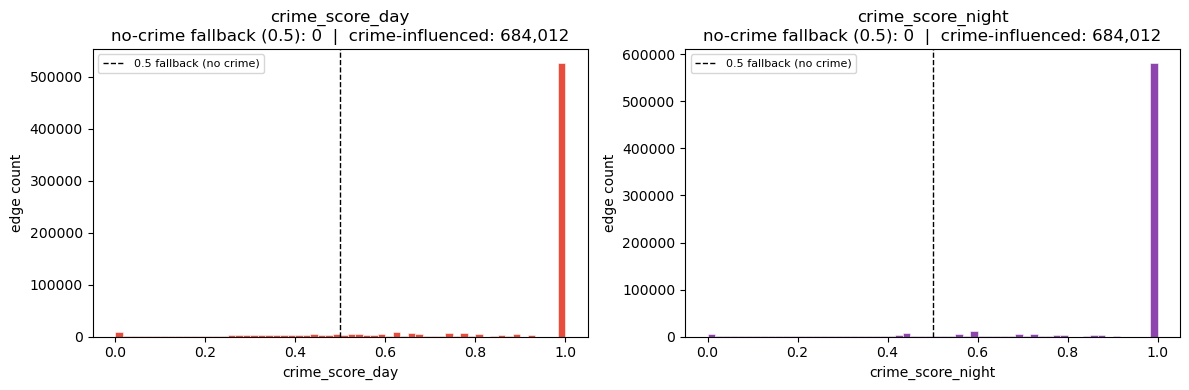

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color in [
    (axes[0], "crime_score_day",   "#e74c3c"),
    (axes[1], "crime_score_night", "#8e44ad"),
]:
    data = edges[col]
    no_crime  = (data == 0.5).sum()
    has_crime = (data != 0.5).sum()
    ax.hist(data, bins=60, color=color, edgecolor='white', linewidth=0.4)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="0.5 fallback (no crime)")
    ax.set_title(f"{col}\nno-crime fallback (0.5): {no_crime:,}  |  crime-influenced: {has_crime:,}")
    ax.set_xlabel(col)
    ax.set_ylabel("edge count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Lighting Score per Edge

`light_score` measures how well-lit each street segment is using city streetlight data.

---

### How It's Computed

**Spatial join (city streetlights)**

Reproject edges and the City of San Diego streetlight dataset to EPSG:3857. Buffer each edge by 30 m. Count how many operational streetlights fall inside that buffer.

- Edges with ≥ 1 nearby streetlight: `score = count / p95`, clipped to [0, 1], where p95 is the 95th-percentile count across lit edges. This prevents a single outlier from compressing the whole distribution.
- Edges with no streetlight within 30 m receive **no `light_score`** (NaN). `infrastructure_score` handles these edges via `road_class_score` directly.

---

### Score Direction

**Higher = better lit = safer at night**

| Score range | Meaning |
|---|---|
| 1.0 | Heavily lit (top 5% of real streetlight counts) |
| 0.5–1.0 | Well-lit segment |
| 0.0–0.5 | Few nearby streetlights |
| NaN | No streetlight within 30 m — falls back to `road_class_score` in `infrastructure_score` |

**Streetlight data source:** `data/processed/streetlights/streetlights_processed.geojson` — 55,506 operational City streetlights filtered to `STATUS = A` and `MAPNG_STAT_CD ∈ {AB, OP}`.

> The 30 m buffer is intentional — a light directly adjacent to the pavement is what matters for pedestrian visibility. A streetlight 50 m away does not illuminate the walking surface.


## Road Type Distribution


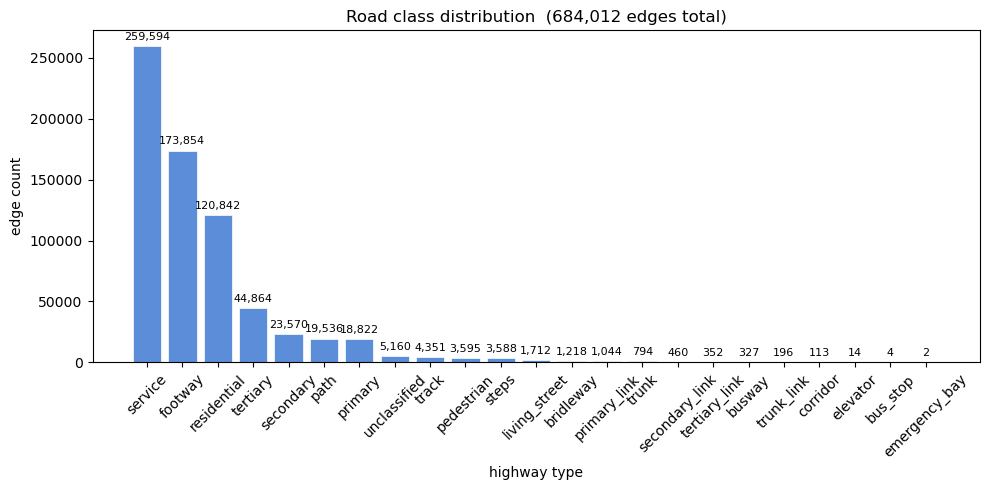

highway
service           259594
footway           173854
residential       120842
tertiary           44864
secondary          23570
path               19536
primary            18822
unclassified        5160
track               4351
pedestrian          3595
steps               3588
living_street       1712
bridleway           1218
primary_link        1044
trunk                794
secondary_link       460
tertiary_link        352
busway               327
trunk_link           196
corridor             113
elevator              14
bus_stop               4
emergency_bay          2


In [28]:
import matplotlib.pyplot as plt

# Flatten highway lists (OSM sometimes returns a list per edge)
highway_clean = edges["highway"].apply(lambda h: h[0] if isinstance(h, list) else h)
counts = highway_clean.value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values, color="#5b8dd9", edgecolor="white", linewidth=0.5)
ax.bar_label(bars, labels=[f"{v:,}" for v in counts.values], padding=3, fontsize=8)
ax.set_title(f"Road class distribution  ({len(edges):,} edges total)")
ax.set_xlabel("highway type")
ax.set_ylabel("edge count")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(counts.to_string())


In [29]:
lights_3857 = light_gdf.to_crs("EPSG:3857")

# Spatial join: count city streetlights within 30 m of each edge
edges_3857 = edges.to_crs("EPSG:3857")
edges_buffered = edges_3857.copy()
edges_buffered["geometry"] = edges_3857.geometry.buffer(30)

joined = gpd.sjoin(edges_buffered[["geometry"]], lights_3857[["geometry"]], how="left", predicate="contains")
raw_lights_counts = joined.groupby(joined.index)["index_right"].count().reindex(edges.index, fill_value=0)

print(raw_lights_counts.describe())
print(f"Edges with 0 lights: {(raw_lights_counts == 0).sum():,}")

has_lights = raw_lights_counts > 0
p95 = raw_lights_counts[has_lights].quantile(0.95)

edges.loc[has_lights, "light_score"] = (raw_lights_counts[has_lights] / p95).clip(0, 1)

print(edges["light_score"].describe())


/Users/mawvir/miniforge3/envs/safe-path/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


count    684012.000000
mean          0.673903
std           1.534040
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          64.000000
Name: index_right, dtype: float64
Edges with 0 lights: 486,780
count    197232.000000
mean          0.365188
std           0.240112
min           0.166667
25%           0.166667
50%           0.333333
75%           0.500000
max           1.000000
Name: light_score, dtype: float64


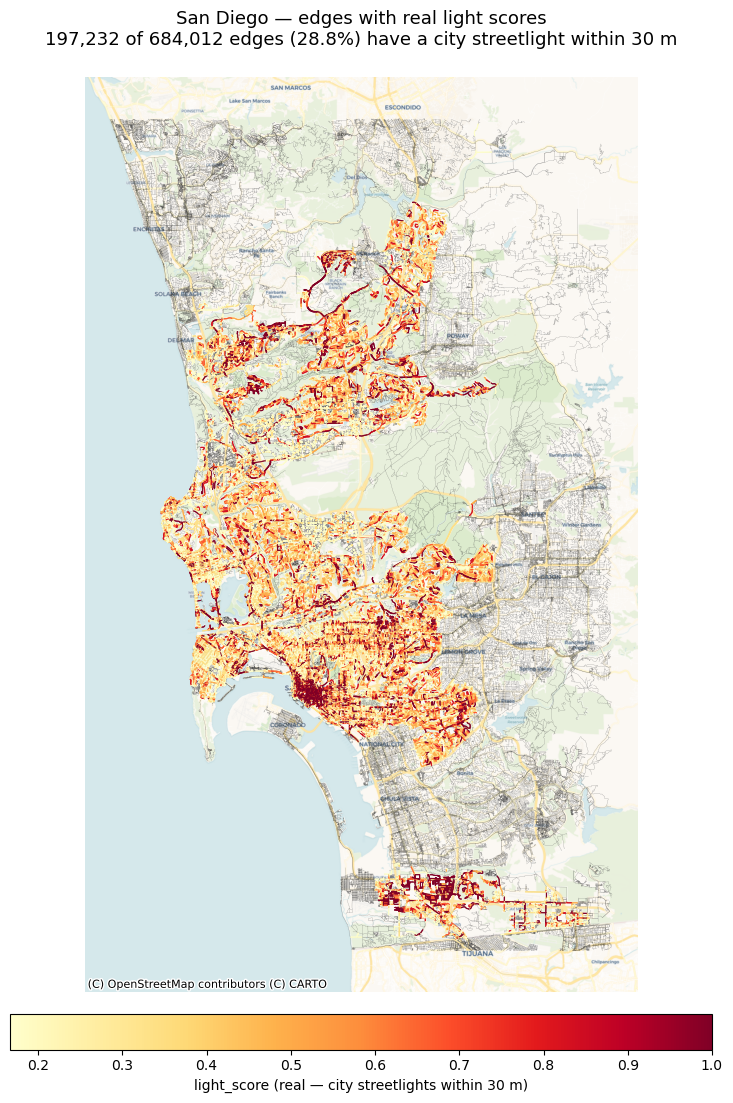

In [30]:
import matplotlib.pyplot as plt
import contextily as ctx

# Plot in EPSG:3857 (Web Mercator) so contextily tiles align correctly
real_edges = edges.loc[raw_lights_counts > 0].to_crs('EPSG:3857')
bg_edges   = edges.to_crs('EPSG:3857')

fig, ax = plt.subplots(figsize=(12, 12))

# Faint network background so roads are visible over the basemap
bg_edges.plot(ax=ax, color='#555555', linewidth=0.2, alpha=0.3, zorder=2)

# Real-scored edges coloured by light_score
real_edges.plot(
    ax=ax,
    column='light_score',
    cmap='YlOrRd',
    linewidth=0.8,
    alpha=0.9,
    legend=True,
    legend_kwds={
        'label': 'light_score (real — city streetlights within 30 m)',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02,
    },
    zorder=3,
)

# Basemap — CartoDB Voyager shows water, parks, and land clearly
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, zoom=12, zorder=1)

ax.set_title(
    f'San Diego — edges with real light scores\n'
    f'{len(real_edges):,} of {len(edges):,} edges ({100*len(real_edges)/len(edges):.1f}%) '
    f'have a city streetlight within 30 m',
    fontsize=13, pad=12
)
ax.set_axis_off()
plt.tight_layout()
plt.show()


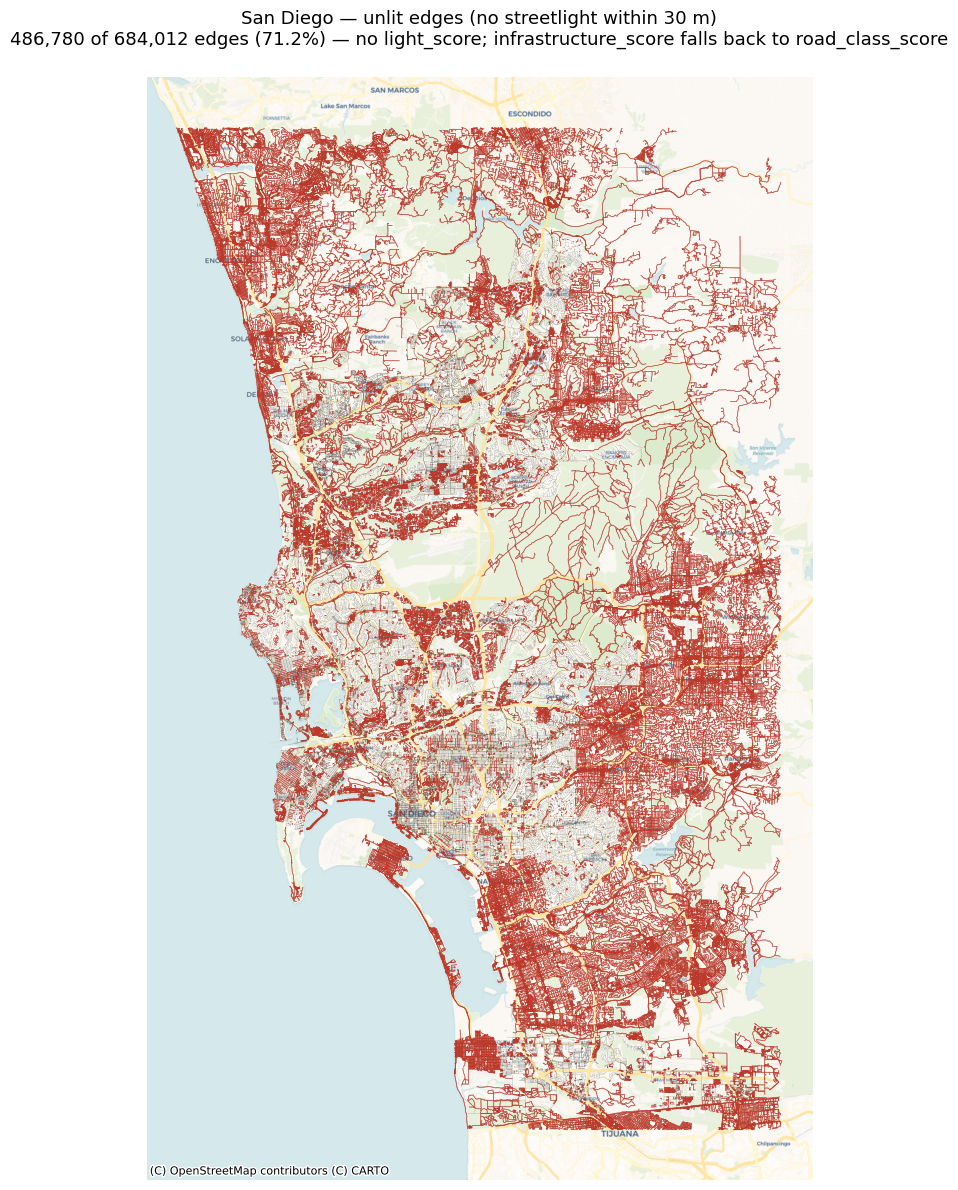

In [31]:
import matplotlib.pyplot as plt
import contextily as ctx

unlit_edges = edges.loc[raw_lights_counts == 0].to_crs('EPSG:3857')
bg_edges    = edges.to_crs('EPSG:3857')

fig, ax = plt.subplots(figsize=(12, 12))

bg_edges.plot(ax=ax, color='#555555', linewidth=0.2, alpha=0.3, zorder=2)
unlit_edges.plot(ax=ax, color='#c0392b', linewidth=0.5, alpha=0.6, zorder=3)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, zoom=12, zorder=1)

ax.set_title(
    f'San Diego — unlit edges (no streetlight within 30 m)\n'
    f'{len(unlit_edges):,} of {len(edges):,} edges ({100*len(unlit_edges)/len(edges):.1f}%) '
    f'— no light_score; infrastructure_score falls back to road_class_score',
    fontsize=13, pad=12
)
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [32]:
edges['light_score'].describe()

count    197232.000000
mean          0.365188
std           0.240112
min           0.166667
25%           0.166667
50%           0.333333
75%           0.500000
max           1.000000
Name: light_score, dtype: float64

# Understanding distribution of score(make sure its not weird)

Lit edges (have light_score)  : 197,232 (28.8%)
Unlit edges (light_score=NaN) : 486,780 (71.2%)


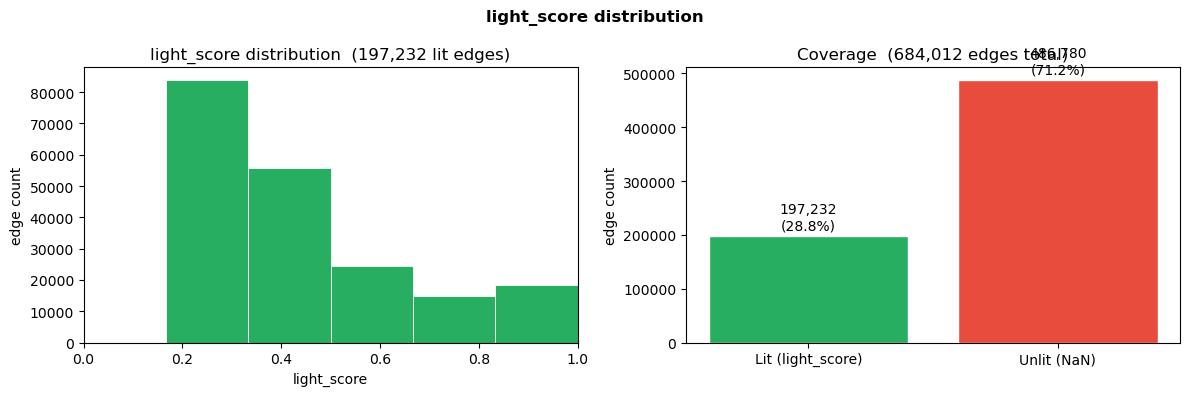

In [33]:
import matplotlib.pyplot as plt
import numpy as np

real_scores = edges.loc[raw_lights_counts > 0, "light_score"]
unlit_count = (raw_lights_counts == 0).sum()

print(f"Lit edges (have light_score)  : {len(real_scores):,} ({100*len(real_scores)/len(edges):.1f}%)")
print(f"Unlit edges (light_score=NaN) : {unlit_count:,} ({100*unlit_count/len(edges):.1f}%)")

p95_val   = raw_lights_counts[raw_lights_counts > 0].quantile(0.95)
real_bins = np.linspace(0, 1, max(int(p95_val), 5) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(real_scores, bins=real_bins, color="#27ae60", edgecolor="white", linewidth=0.6)
axes[0].set_title(f"light_score distribution  ({len(real_scores):,} lit edges)")
axes[0].set_xlabel("light_score")
axes[0].set_ylabel("edge count")
axes[0].set_xlim(0, 1)

axes[1].bar(["Lit (light_score)", "Unlit (NaN)"],
            [len(real_scores), unlit_count],
            color=["#27ae60", "#e74c3c"], edgecolor="white")
axes[1].set_title(f"Coverage  ({len(edges):,} edges total)")
axes[1].set_ylabel("edge count")
axes[1].bar_label(
    axes[1].containers[0],
    labels=[f"{len(real_scores):,}\n({100*len(real_scores)/len(edges):.1f}%)",
            f"{unlit_count:,}\n({100*unlit_count/len(edges):.1f}%)"],
    padding=3
)

plt.suptitle("light_score distribution", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Walkability score per edge

`walk_score` is derived from the EPA National Walkability Index (`NatWalkInd`), which rates each census block group on a 1–20 scale based on street network density, intersection density, and proximity to destinations. Higher means more walkable.

**How it's mapped to edges:**
1. Reproject edges and block group polygons to EPSG:3857.
2. Compute the midpoint of each edge with `interpolate(0.5, normalized=True)` — a single point that lands unambiguously in one polygon. This avoids double-counting when a long edge crosses two block groups.
3. Spatial join: assign the `NatWalkInd` of whichever polygon the midpoint falls within (`predicate="within"`).
4. Normalise to [0, 1]: `walk_score = (NatWalkInd - 1) / 19`.
5. Edges whose midpoint doesn't land in any polygon get a fallback of **0.5** (neutral).

**Score direction:** higher = more walkable neighbourhood = better pedestrian infrastructure.

**Source:** `data/processed/walkability_final_gdf.gpkg` — EPA Walkability Index joined to San Diego census block groups.

In [34]:

# Reproject to match edges
walk_gdf_3857 = walkability_gdf.to_crs("EPSG:3857")

# Midpoint of each edge
#  interpolate(0.5, normalized=True) gives the midpoint along the edge geometry
edges_mid = edges_3857.copy()
edges_mid["geometry"] = edges_mid.geometry.interpolate(0.5, normalized=True)

# Spatial join midpoint with walkability block group polygon
# predicate: "within" — only assign walkability score if midpoint falls within the block group polygon
# only need NatWalkInd and geometry from walkability_gdf for this join

joined_walk = gpd.sjoin(edges_mid[["geometry"]],
                        walk_gdf_3857[["NatWalkInd", "geometry"]],
                        how="left",
                        predicate="within")

# Normalize NatWalkInd to 0-1 range
edges['walk_score'] = ((joined_walk["NatWalkInd"] - 1)/19).fillna(0.5).values


In [35]:
# Check 1 — fallback rate
walk_fallback = (edges["walk_score"] == 0.5).sum()
print(f"Walk fallback: {walk_fallback:,} ({100*walk_fallback/len(edges):.1f}%)")

# Check 2 — real score variation
real_walk = edges[edges["walk_score"] != 0.5]["walk_score"]
print(real_walk.describe())

Walk fallback: 238,722 (34.9%)
count    445290.000000
mean          0.607739
std           0.200832
min           0.052632
25%           0.438596
50%           0.640351
75%           0.754386
max           0.982456
Name: walk_score, dtype: float64


count    684012.000000
mean          0.570138
std           0.169983
min           0.052632
25%           0.500000
50%           0.500000
75%           0.701754
max           0.982456
Name: walk_score, dtype: float64
Any above 1? False
Any below 0? False


<Axes: >

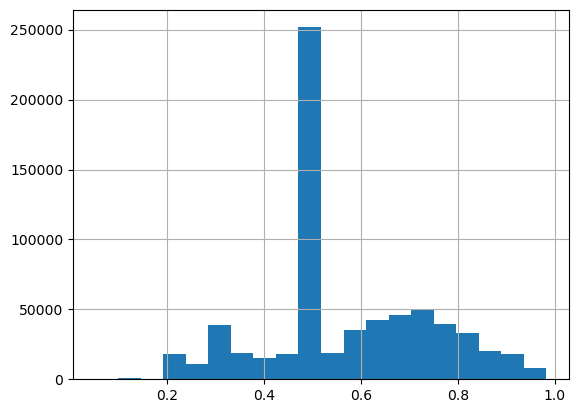

In [36]:
# Sanity Check 
print(edges["walk_score"].describe())
print("Any above 1?", (edges["walk_score"] > 1).any())
print("Any below 0?", (edges["walk_score"] < 0).any())

# Also check distribution looks reasonable
# Most San Diego edges should cluster around 0.4-0.7
edges["walk_score"].hist(bins=20)


In [37]:
# How many edges got a real score vs the 0.5 fallback
real_scores = (edges["walk_score"] != 0.5).sum()
fallback = (edges["walk_score"] == 0.5).sum()
print(f"Real scores: {real_scores}")
print(f"Fallback 0.5: {fallback}")

# Check CRS of both before the join
print(edges_mid.crs)
print(walk_gdf_3857.crs)

# Check if midpoints are actually inside San Diego bbox
print(edges_mid.geometry.total_bounds)
print(walk_gdf_3857.geometry.total_bounds)

Real scores: 445290
Fallback 0.5: 238722
EPSG:3857
EPSG:3857
[-13060416.63674213   3833612.4935482  -13014098.03930676
   3910485.46244185]
[-13090788.5103237    3833714.55559786 -12958859.55164394
   3962531.04870774]


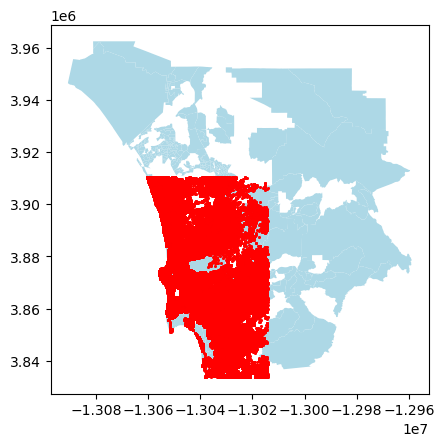

In [38]:
# Plot both to visually confirm they overlap
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
walk_gdf_3857.plot(ax=ax, color="lightblue")
edges_mid.plot(ax=ax, color="red", markersize=1)
plt.show()

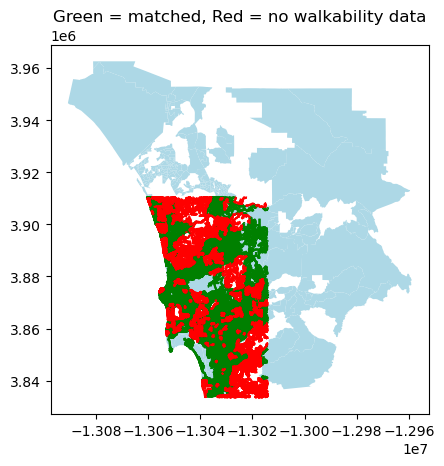

In [39]:
# Plot just the unmatched edges to see where they are
unmatched = edges[edges["walk_score"] == 0.5]
matched = edges[edges["walk_score"] != 0.5]

fig, ax = plt.subplots()
walk_gdf_3857.plot(ax=ax, color="lightblue")
matched.to_crs("EPSG:3857").plot(ax=ax, color="green", markersize=1)
unmatched.to_crs("EPSG:3857").plot(ax=ax, color="red", markersize=1)
plt.title("Green = matched, Red = no walkability data")
plt.show()

### Why are ~35% of edges red (no walkability match)?

Red edges received the 0.5 fallback because their midpoint didn't land inside any census block group polygon. This is expected and breaks down into a few well-understood categories.

**Large red zone on the west — ocean and coastline**
Census block groups are land-based administrative units. No block group geometry covers open water, so every walking path along the coast — boardwalks, beach paths, pier walkways — falls back to 0.5. This is not a data error.

**Scattered red patches through the city — parks, military land, and non-residential zones**

| Area | Why no block group |
| - | - |
| Balboa Park | San Diego's largest urban park has extensive OSM walking paths but no residential block group covers it |
| Mission Bay / Mission Valley | Water and recreational parkland with walking paths but no residential census coverage |
| MCAS Miramar, NAS North Island, Naval Station SD | Federal military land — no civilian census block groups exist on base |
| Industrial and commercial zones | Areas with zero residential population are often outside any block group boundary |

**What this means for routing**
These edges are not broken — they just have no walkability data. The 0.5 fallback is deliberately neutral: the router will not prefer or avoid them on walkability grounds alone. Crime and lighting scores still apply to all edges including these, so routing still functions correctly in parks, along the coast, and near military areas.

In [40]:
# Pedestrian suitability: higher = more appropriate for walking.
# Reflects traffic exposure and road designation, not lighting.
road_class_map = {
    "footway":       1.00,
    "pedestrian":    1.00,
    "path":          0.90,
    "cycleway":      0.85,
    "living_street": 0.80,
    "residential":   0.70,
    "unclassified":  0.60,
    "tertiary":      0.50,
    "secondary":     0.35,
    "primary":       0.20,
    "trunk":         0.10,
    "motorway":      0.00,
}

def get_road_class_score(val):
    if isinstance(val, list):
        val = val[0]
    return road_class_map.get(val, 0.5)

edges["road_class_score"] = edges["highway"].map(get_road_class_score)

print("road_class_score value counts (score → count):")
print(edges["road_class_score"].value_counts().sort_index(ascending=False).to_string())
print()
print(edges["road_class_score"].describe().round(3))
print()
fallback_road = (edges["road_class_score"] == 0.5).sum()
print(f"Fallback 0.5 edges (highway not in map): {fallback_road:,}  ({100*fallback_road/len(edges):.1f}%)")


road_class_score value counts (score → count):
road_class_score
1.00    177449
0.90     19536
0.80      1712
0.70    120842
0.60      5160
0.50    316127
0.35     23570
0.20     18822
0.10       794

count    684012.000
mean          0.664
std           0.231
min           0.100
25%           0.500
50%           0.500
75%           1.000
max           1.000
Name: road_class_score, dtype: float64

Fallback 0.5 edges (highway not in map): 316,127  (46.2%)


In [41]:
# SD Street Design Manual — Lighting Update 2016 (§A.2–§A.6)
# Expected lighting level by road class — used as the lighting signal
# for edges with no city streetlight within 30 m.
LIGHTING_CLASS = {
    "motorway":      0.85,  "motorway_link":  0.80,  # §A.3b: 4-lane urban major, midblock ≤300 ft
    "trunk":         0.80,  "trunk_link":     0.75,  # §A.3b: major arterials continuously lit
    "primary":       0.75,  "primary_link":   0.70,  # §A.3b
    "secondary":     0.65,  "secondary_link": 0.60,  # §A.3b
    "pedestrian":    0.65,                          # §A.6(1): IES RP-8 High Pedestrian Conflict
    "tertiary":      0.55,  "tertiary_link":  0.50,  # §A.3a: partial, near transit or high-crime
    "residential":   0.45,  "living_street":  0.45,  # §A.3a: location-dependent
    "unclassified":  0.40,  "steps":          0.40,  # §A.3e: conservative neutral
    "service":       0.35,                          # §A.5(1): Type X lowest-priority (refined by subtype below)
    "footway":       0.30,  "cycleway":       0.30,  # §A.4: open space exemption
    "path":          0.25,                          # §A.4: lighting not guaranteed
    "track":         0.20,  "bridleway":      0.20,  # §A.4: explicitly exempted
}

def _first(val):
    return val[0] if isinstance(val, list) else val

edges["lighting_class_score"] = edges["highway"].apply(_first).map(LIGHTING_CLASS).fillna(0.40)

# Refine `service` edges by OSM subtype — flat 0.35 treats all service roads
# identically, but parking lots (IES RP-20) and drive-throughs are lit for
# commercial/liability reasons while alleys and driveways are not.
SERVICE_LIGHTING = {
    "drive-through":    0.55,  # commercial, lit during operation hours
    "parking_aisle":    0.50,  # IES RP-20: parking facilities min illuminance standard
    "parking":          0.50,  # same environment as parking_aisle
    "car_wash":         0.45,  # commercial, usually lit
    "access":           0.35,  # generic — keep base score
    "alley":            0.30,  # §A.5(1): lowest-priority luminaire class in SD Manual
    "driveway":         0.25,  # private property, no lighting obligation
    "emergency_access": 0.25,  # gated, unlit by design
    "yard":             0.25,  # private yard, incidental lighting at best
    "slipway":          0.20,  # waterfront ramp — no fixed lighting infrastructure
}

if "service" in edges.columns:
    service_idx = edges.index[edges["highway"].apply(_first) == "service"]
    subtypes    = edges.loc[service_idx, "service"].apply(_first)
    refined     = subtypes.map(SERVICE_LIGHTING)
    has_subtype = refined.notna()
    known_idx   = service_idx[has_subtype.values]
    edges.loc[known_idx, "lighting_class_score"] = refined[has_subtype].values
    print(f"Service subtype refinement: {has_subtype.sum():,} of {len(service_idx):,} service edges refined")

print("\nlighting_class_score value counts:")
print(edges["lighting_class_score"].value_counts().sort_index(ascending=False).to_string())


Service subtype refinement: 109,252 of 259,594 service edges refined

lighting_class_score value counts:
lighting_class_score
0.80       794
0.75     19018
0.70      1044
0.65     27165
0.60       460
0.55     46771
0.50     68396
0.45    122556
0.40      9208
0.35    150346
0.30    187097
0.25     45582
0.20      5575


## Infrastructure Score per Edge

`infrastructure_score` is the main physical-environment signal for each edge. It combines a **lighting signal** (60% weight) with **pedestrian road suitability** (40% weight).

---

### Formula

**`infrastructure_score = 0.6 × lighting_signal + 0.4 × road_class_score`**

The formula structure is identical for all edges. The lighting signal changes based on whether real streetlight data exists:

| Edge type | Lighting signal | Source |
|---|---|---|
| Lit (~28.8%) | `light_score` | City streetlight count / p95, clipped [0, 1] |
| Unlit (~71.2%) | `lighting_class_score` | SD Street Design Manual §A.2–§A.6 expected lighting per road class |

---

### Component Scores

**`road_class_score`** — Pedestrian suitability. Higher = more appropriate for walking. Reflects traffic exposure and road designation, not lighting.

| Road type | Score |
|---|---|
| `footway` / `pedestrian` | 1.00 |
| `path` | 0.90 |
| `cycleway` | 0.85 |
| `living_street` | 0.80 |
| `residential` | 0.70 |
| `unclassified` | 0.60 |
| `tertiary` | 0.50 |
| `secondary` | 0.35 |
| `primary` | 0.20 |
| `trunk` | 0.10 |
| `motorway` | 0.00 |

**`lighting_class_score`** — Expected illumination per road class, from the **City of San Diego Street Design Manual — Lighting Update 2016**. Used as the lighting signal for unlit edges.

| OSM highway type | Score | Manual rule |
|---|---|---|
| `motorway` / `motorway_link` | 0.85 / 0.80 | §A.3b: midblock lighting ≤300 ft on 4-lane urban major |
| `trunk` / `trunk_link` | 0.80 / 0.75 | §A.3b: major arterials continuously lit |
| `primary` / `primary_link` | 0.75 / 0.70 | §A.3b |
| `secondary` / `secondary_link` | 0.65 / 0.60 | §A.3b |
| `pedestrian` | 0.65 | §A.6(1): IES RP-8 High Pedestrian Conflict — highest spec |
| `tertiary` / `tertiary_link` | 0.55 / 0.50 | §A.3a: partial — near transit stops or high-crime areas |
| `residential` / `living_street` | 0.45 | §A.3a: location-dependent |
| `unclassified` / `steps` | 0.40 | §A.3e: conservative neutral |
| `service` | 0.35 (base) | §A.5(1): Type X lowest-priority luminaire — refined by subtype below |
| `footway` / `cycleway` | 0.30 | §A.4: open space exemption |
| `path` | 0.25 | §A.4: lighting not guaranteed |
| `track` / `bridleway` | 0.20 | §A.4: explicitly exempted from lighting mandate |

**`service` subtype refinement** — The base 0.35 is refined using the OSM `service` subtag, which reveals meaningfully different lighting environments within a single road class:

| OSM `service` subtype | Score | Justification |
|---|---|---|
| `drive-through` | 0.55 | Commercial operation — lit during business hours for customer/employee safety |
| `parking_aisle` / `parking` | 0.50 | IES RP-20 sets minimum illuminance for parking facilities (security/liability) |
| `car_wash` | 0.45 | Commercial, usually lit; lower than parking as often closed at night |
| `access` | 0.35 | Generic — keep base score |
| `alley` | 0.30 | §A.5(1): lowest-priority luminaire class in SD Manual |
| `driveway` | 0.25 | Private property — no public lighting obligation |
| `emergency_access` | 0.25 | Gated, unlit by design |
| `yard` | 0.25 | Private yard — incidental lighting at best |
| `slipway` | 0.20 | Waterfront boat ramp — no fixed lighting infrastructure |

> **Source:** City of San Diego Street Design Manual — Lighting Update 2016, §A.2–§A.6

---

### Why only `service` gets subtype refinement

All other edge attributes available in `sd_walk_graph.graphml` were evaluated and rejected:

| Column | Coverage | Reason not refined |
|---|---|---|
| `bridge` | ~2,800 edges (0.4%) | Lit bridges are already captured by the 30 m streetlight spatial join; no reliable proxy for unlit ones |
| `access` | ~10,400 edges (1.5%) | Values (`customers`, `no`, `permissive`) appear almost entirely on `service` roads, which are already refined by subtype — adding `access` would double-count |
| `junction` | ~670 edges (0.1%) | All roundabouts; lighting expectation already set by the underlying highway class |
| `tunnel` | 1 edge | Not worth a special case |
| `footway` subtype | — | Tag not exported into this graphml |

`service` is the only highway class where OSM records a subtype that (a) is present at meaningful scale and (b) encodes genuinely different lighting environments that the flat class score cannot capture.

---

### Score Direction

Higher = better physical environment for pedestrian safety.

| Score | Interpretation |
|---|---|
| 0.8–1.0 | Well-lit pedestrian path or plaza |
| 0.6–0.8 | Lit residential or secondary road |
| 0.4–0.6 | Unlit residential / tertiary, or lit arterial |
| 0.2–0.4 | Dark path, alley, or service road |

### Coverage

| Source | Edges | Share |
|---|---|---|
| Real streetlight data + road class | ~197,000 | ~28.8% |
| SD Manual lighting proxy + road class | ~487,000 | ~71.2% |

---


### Known Limitation & Weight Guidance

The 71.2% of unlit edges produce a near-discrete distribution — 5–6 point masses clustered in 0.40–0.58 — because `lighting_class_score` is purely categorical.

Because of this, **weighting `infrastructure_score` too heavily makes routing decisions for 71% of the network reduce to road-type classification**, ignoring crime and walkability. Recommended weight budget:

| Score | Suggested weight | Rationale |
|---|---|---|
| `crime_score` | ~60–65% | Continuous, spatially rich, directly measures pedestrian danger |
| `walk_score` | ~20–25% | Continuous per census block group, captures neighbourhood walkability |
| `infrastructure_score` | ~15% | Strong signal for lit edges; near-flat for unlit — keep modest |

> If you push `infrastructure_score` above ~20%, verify that routing on unlit edges still produces sensible results — road type becomes a dominant factor at that point.


In [43]:
# Formula: 0.6 * [lighting signal] + 0.4 * road_class_score
# Lit edges use real streetlight density; unlit use SD Manual proxy.

edges["infrastructure_score"] = (
    0.6 * edges["lighting_class_score"] + 0.4 * edges["road_class_score"]
)

edges.loc[has_lights, "infrastructure_score"] = (
    0.6 * edges.loc[has_lights, "light_score"] +
    0.4 * edges.loc[has_lights, "road_class_score"]
)

print(f"Lit   (light_score + road_class):    {has_lights.sum():,} ({100*has_lights.mean():.1f}%)")
print(f"Unlit (lighting_class + road_class): {(~has_lights).sum():,} ({100*(~has_lights).mean():.1f}%)")
print()
print(edges["infrastructure_score"].describe().round(3))


Lit   (light_score + road_class):    197,232 (28.8%)
Unlit (lighting_class + road_class): 486,780 (71.2%)

count    684012.000
mean          0.498
std           0.117
min           0.140
25%           0.410
50%           0.500
75%           0.580
max           1.000
Name: infrastructure_score, dtype: float64


In [44]:
# Sanity checks
ok_range = ((edges['infrastructure_score'] >= 0) & (edges['infrastructure_score'] <= 1)).all()
ok_nan   = edges['infrastructure_score'].notna().all()
print('Range [0, 1]:', 'PASS' if ok_range else 'FAIL')
print('No NaN:      ', 'PASS' if ok_nan   else 'FAIL')

if 'service' in edges.columns:
    svc = edges[edges['highway'].apply(_first) == 'service'].copy()
    svc['subtype'] = svc['service'].apply(_first)
    parking = svc.loc[svc['subtype'] == 'parking_aisle', 'infrastructure_score'].mean()
    alley   = svc.loc[svc['subtype'] == 'alley',          'infrastructure_score'].mean()
    if pd.notna(parking) and pd.notna(alley):
        print(f'parking_aisle ({parking:.3f}) > alley ({alley:.3f}):', 'PASS' if parking > alley else 'FAIL')


Range [0, 1]: PASS
No NaN:       PASS
parking_aisle (0.481) > alley (0.373): PASS


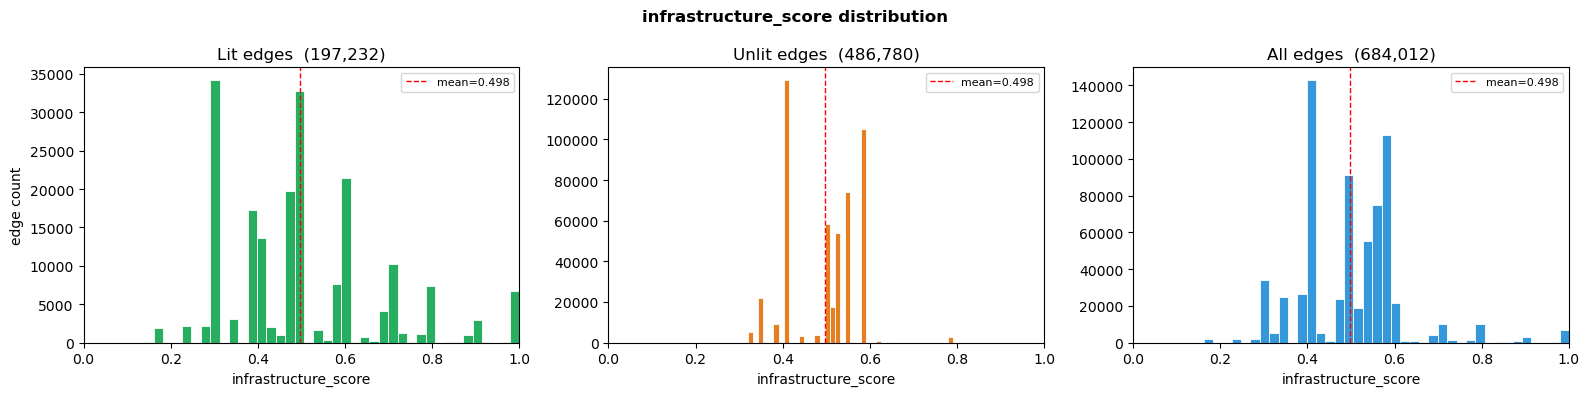

In [45]:
import matplotlib.pyplot as plt
import numpy as np

lit_scores   = edges.loc[has_lights,  'infrastructure_score']
unlit_scores = edges.loc[~has_lights, 'infrastructure_score']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(lit_scores,   bins=40, color='#27ae60', edgecolor='white', linewidth=0.6)
axes[0].set_title(f'Lit edges  ({len(lit_scores):,})')
axes[0].set_xlabel('infrastructure_score')
axes[0].set_ylabel('edge count')
axes[0].set_xlim(0, 1)

axes[1].hist(unlit_scores, bins=40, color='#e67e22', edgecolor='white', linewidth=0.6)
axes[1].set_title(f'Unlit edges  ({len(unlit_scores):,})')
axes[1].set_xlabel('infrastructure_score')
axes[1].set_xlim(0, 1)

axes[2].hist(edges['infrastructure_score'], bins=40, color='#3498db', edgecolor='white', linewidth=0.6)
axes[2].set_title(f'All edges  ({len(edges):,})')
axes[2].set_xlabel('infrastructure_score')
axes[2].set_xlim(0, 1)

for ax in axes:
    ax.axvline(edges['infrastructure_score'].mean(), color='red', linewidth=1, linestyle='--', label=f'mean={edges["infrastructure_score"].mean():.3f}')
    ax.legend(fontsize=8)

plt.suptitle('infrastructure_score distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [46]:
# Save just the raw scores — these never change
# safety_score and safety_cost are NOT saved because
# they depend on weights and multipliers that are still being tuned
# crime_score_day/night are derived aliases at load time — not saved

edges[[
    'crime_score_short_day',  'crime_score_short_night',
    'crime_score_medium_day', 'crime_score_medium_night',
    'crime_score_long_day',   'crime_score_long_night',
    'walk_score',
    'infrastructure_score'
]].to_csv('../data/processed/edge_scores.csv')
print('Saved edge_scores.csv')


Saved edge_scores.csv
